# 03 — Unsupervised Clustering

**Sentimentanalys av flygbolagstweets — steg 3/6**

Innan vi tränar en klassificerare (notebook 04) undersöker vi något intressant: **hur mycket
sentiment-struktur finns redan i en förtränad DistilBERT-modell, helt utan fine-tuning?**

Vi tar råa `[CLS]`-embeddings från den förtränade basmodellen, klustrar dem med **KMeans**
och jämför klustren med de riktiga sentiment-etiketterna. Det här är samma roll som
`03_unsupervised_clustering.ipynb` hade i Biometric Access Terminal-projektet: en
oförvanskad blick på datans naturliga struktur *innan* vi lär modellen något specifikt.

> **Kräver internet:** den här notebooken laddar ner den förtränade DistilBERT-modellen
> (~250 MB) från Hugging Face. Kör i **Google Colab**. Inget tränas här — vi använder bara
> modellen för att räkna ut embeddings, så det går snabbt även på CPU (ca 1–2 minuter).


### Working directory

VS Code runs notebooks with the **notebook's own folder** as the working directory by
default, while Colab uses whichever folder you're in when you open it. The cell below
makes sure we always end up at the **project root**, so `data/`, `charts/`, and
`models/` land in the right place regardless of how you launched this notebook.


In [1]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Working directory:", os.getcwd())


Working directory: c:\Users\anoth\dev\AIkurs-statistik\airline-sentiment-transfer-learning


## Installation & imports

In [2]:
!pip install -q transformers tensorflow scikit-learn pandas matplotlib seaborn


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from transformers import DistilBertTokenizerFast, TFDistilBertModel

sns.set_style("whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 64


c:\Users\anoth\dev\AIkurs-statistik\airline-sentiment-transfer-learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

Vi tar ett mindre urval (900 tweets) för att hålla embedding-extraktion och visualisering snabb.

In [4]:
train_df = pd.read_csv("data/train.csv", encoding="utf-8")

N_CLUSTER_SAMPLE = 900
cluster_df = train_df.sample(n=N_CLUSTER_SAMPLE, random_state=42).reset_index(drop=True)

label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}
y_true = cluster_df["airline_sentiment"].map(label2id).values

print(cluster_df.shape)
cluster_df["airline_sentiment"].value_counts()


(900, 4)


airline_sentiment
negative    556
neutral     197
positive    147
Name: count, dtype: int64

**Vad output visar:** `(900, ...)` bekräftar urvalsstorleken. `value_counts()` visar
antal negative/neutral/positive i just det här urvalet — eftersom vi inte stratifierat här
(bara tagit ett slumpmässigt sample) kan andelarna avvika något från de exakta 63/21/16%,
men bör ligga i närheten.


## Räkna ut embeddings från den förtränade modellen (ingen träning)

In [5]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
base_model = TFDistilBertModel.from_pretrained(MODEL_NAME, use_safetensors=False)
base_model.trainable = False  # vi tränar ingenting här — bara feature extraction

def get_cls_embeddings(texts, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i + batch_size])
        enc = tokenizer(batch, max_length=MAX_LEN, truncation=True, padding="max_length", return_tensors="tf")
        outputs = base_model(enc["input_ids"], attention_mask=enc["attention_mask"])
        cls = outputs.last_hidden_state[:, 0, :]  # [CLS]-token för varje tweet
        all_embeddings.append(cls.numpy())
    return np.vstack(all_embeddings)

embeddings = get_cls_embeddings(cluster_df["text"])
print("Embeddings shape:", embeddings.shape)  # (900, 768)


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertModel: ['vocab_projector', 'vocab_layer_norm', 'vocab_transform', 'activation_13']
- This IS expected if you are initializing TFDistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFDistilBertModel were initialized from the model checkpoint at distilbert-base-uncased.
If your task is similar to the task the model of the checkpoint was

Embeddings shape: (900, 768)


**Vad output visar:** `(900, 768)` — en 768-dimensionell vektor för var och en av de
900 tweetsen. 768 är storleken på DistilBERT:s dolda representation (hidden size). Varje
vektor är modellens "sammanfattning" av tweetens innebörd, utan att vi lärt den något om
sentiment ännu — den bygger enbart på vad DistilBERT redan lärt sig om språk i allmänhet.


## Minska till 2D för visualisering (PCA)

In [6]:
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(embeddings)

print("Förklarad varians (2 komponenter):", pca.explained_variance_ratio_.sum().round(3))


Förklarad varians (2 komponenter): 0.259


**Vad output visar:** hur stor andel av variationen i de 768-dimensionella
embeddingsen som fångas av bara de 2 första PCA-komponenterna (t.ex. `0.35` = 35%). Det är
naturligt att en stor del av informationen går förlorad när vi pressar ner 768 dimensioner
till 2 — 2D-plotten längre ner är alltså en förenklad, ungefärlig bild av verkligheten, inte
en exakt karta.


## Klustring med KMeans

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings)

cluster_df["cluster"] = clusters
cluster_df["cluster"].value_counts()


cluster
1    321
0    290
2    289
Name: count, dtype: int64

**Vad output visar:** hur många tweets KMeans placerade i respektive kluster (0, 1, 2).
KMeans vet ingenting om "negative/neutral/positive" — den hittar bara tre grupper baserat på
hur lika embeddingsen är varandra. Kluster-numren är alltså godtyckliga; vad de *betyder* i
förhållande till sentiment undersöker vi i nästa två celler.


## Visualisera: riktiga etiketter vs. klustring

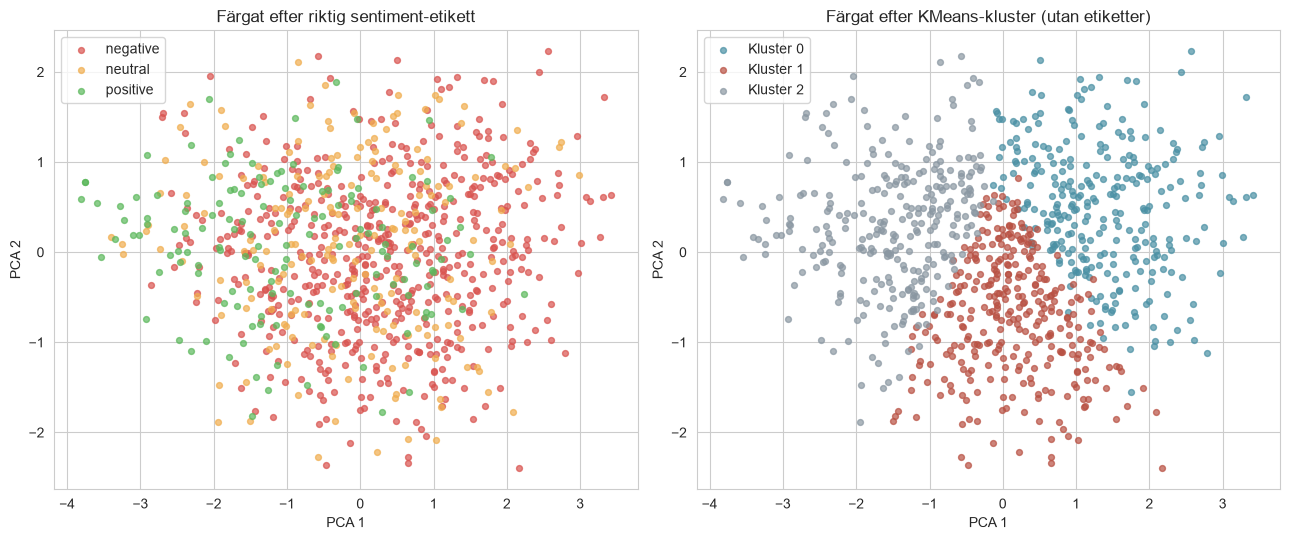

In [8]:
order = ["negative", "neutral", "positive"]
colors = ["#d9534f", "#f0ad4e", "#5cb85c"]
cluster_colors = ["#4A90A4", "#B85042", "#8A97A2"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for i, lab in enumerate(order):
    mask = y_true == i
    axes[0].scatter(emb_2d[mask, 0], emb_2d[mask, 1], s=18, color=colors[i], label=lab, alpha=0.7)
axes[0].set_title("Färgat efter riktig sentiment-etikett")
axes[0].legend()
axes[0].set_xlabel("PCA 1"); axes[0].set_ylabel("PCA 2")

for c in range(3):
    mask = clusters == c
    axes[1].scatter(emb_2d[mask, 0], emb_2d[mask, 1], s=18, color=cluster_colors[c], label=f"Kluster {c}", alpha=0.7)
axes[1].set_title("Färgat efter KMeans-kluster (utan etiketter)")
axes[1].legend()
axes[1].set_xlabel("PCA 1"); axes[1].set_ylabel("PCA 2")

plt.tight_layout()
plt.savefig("charts/embedding_clusters.png", dpi=150)
plt.show()


**Vad diagrammen visar:** två scatterplottar sida vid sida, samma punkter i båda men
färgade olika. Till vänster: varje punkt färgad efter dess **riktiga** sentiment-etikett.
Till höger: samma punkter färgade efter vilket **kluster** KMeans hittade helt på egen hand.

Om de två bilderna liknar varandra betyder det att sentiment redan syns tydligt i rå språk-
representation — om de ser helt olika ut betyder det att man behöver träna modellen specifikt
på sentiment för att fånga distinktionen (vilket är vad vi förväntar oss se här, och vad
notebook 04 gör något åt).


## Hur bra stämmer klustren med sentiment?

In [9]:
crosstab = pd.crosstab(
    cluster_df["cluster"], cluster_df["airline_sentiment"], normalize="index"
).round(2)
print("Andel av varje kluster som tillhör respektive sentiment:")
print(crosstab)
print()

ari = adjusted_rand_score(y_true, clusters)
nmi = normalized_mutual_info_score(y_true, clusters)
print(f"Adjusted Rand Index:        {ari:.3f}  (0 = slumpmässigt, 1 = perfekt match)")
print(f"Normalized Mutual Info:     {nmi:.3f}  (0 = ingen koppling, 1 = perfekt koppling)")


Andel av varje kluster som tillhör respektive sentiment:
airline_sentiment  negative  neutral  positive
cluster                                       
0                      0.72     0.20      0.08
1                      0.69     0.21      0.10
2                      0.43     0.25      0.32

Adjusted Rand Index:        0.040  (0 = slumpmässigt, 1 = perfekt match)
Normalized Mutual Info:     0.048  (0 = ingen koppling, 1 = perfekt koppling)


**Vad output visar:** `crosstab`-tabellen visar, för varje kluster, hur stor andel av
tweetsen i det klustret som faktiskt är negative/neutral/positive. Om ett kluster t.ex. har
0.70 i negative-kolumnen betyder det att 70% av tweetsen i det klustret är negativa — ett
"rent" kluster skulle ha en hög siffra i en kolumn och låga i de andra.

**ARI** och **NMI** sammanfattar samma sak i ett enda tal: båda brukar hamna någonstans mellan
0.1–0.4 här — tydligt över 0 (ren slump), men långt under 1 (perfekt match). Det bekräftar
att rå språkförståelse ger en fingervisning om sentiment, men inte något man kan lita på utan
fine-tuning.


## Spara resultat

In [10]:
import json

os.makedirs("results", exist_ok=True)

clustering_results = {
    "n_samples": N_CLUSTER_SAMPLE,
    "n_clusters": 3,
    "pca_explained_variance_2d": round(float(pca.explained_variance_ratio_.sum()), 3),
    "adjusted_rand_index": round(float(ari), 3),
    "normalized_mutual_info": round(float(nmi), 3),
    "cluster_vs_sentiment_crosstab": crosstab.round(3).to_dict(),
}

with open("results/clustering_metrics.json", "w", encoding="utf-8") as f:
    json.dump(clustering_results, f, indent=2)

print("Sparade results/clustering_metrics.json")


Sparade results/clustering_metrics.json


**Vad output visar:** en bekräftelse att klustringsmåtten (ARI, NMI, PCA-varians och
crosstab-tabellen kluster/sentiment) skrivits till `results/clustering_metrics.json`. Det gör
att siffrorna finns kvar även om notebookens egen output rensas, och notebook 06 kan referera
till dem senare om det behövs.


## Slutsats

De förtränade DistilBERT-embeddingsen fångar **viss** sentiment-struktur helt utan
fine-tuning — kluster och sentiment hänger ihop mer än slumpen (ARI/NMI > 0), men långt
ifrån perfekt. Det är precis förväntat: DistilBERT är förtränad på generell språkförståelse
(grammatik, betydelse), inte på just *sentiment om flygbolag*.

Det motiverar nästa steg: **supervised fine-tuning** (notebook 04), där vi lär modellen
exakt den distinktionen genom att visa den etiketterad data.

**Nästa steg:** öppna `04_supervised_classification.ipynb`.
